# ML - REGRESION LINEAL

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

## Paso 1: Definicion del problema (target)
Predecir el coste del seguro medico de un cliente, la tenemos localizada en la variable `charges`

## Paso 2: Recopilacion de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv)

### Importamos los datos y creamos el DataFrame

In [25]:
df = pd.read_csv('../data/raw/medical_insurance_cost.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Paso 3: Realizamos un EDA completo

### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(1338, 7)

In [5]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [26]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


> ## Observaciones:
>
> - Existen un total de 1338 filas (en este caso, personas o beneficiarios) y 7 columnas, entre las cuales está el target a predecir, `charges`
> - Todas las columnas cuentan siempre con valor, no tienen valores nulos.
> - Los datos constan de 4 variables numéricas y 3 categóricas

### Limpieza de datos

In [27]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [28]:
df[df['charges'] == 1639.5631]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [29]:
df.drop_duplicates(inplace=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


> ## Conclusiones:
>
> - Eliminamos 1 registro duplicados, pasamos a tener ahora 1337 filas
> - De momento conservamos todas las variables porque nos pueden aportar informacion relevante para la prediccion

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

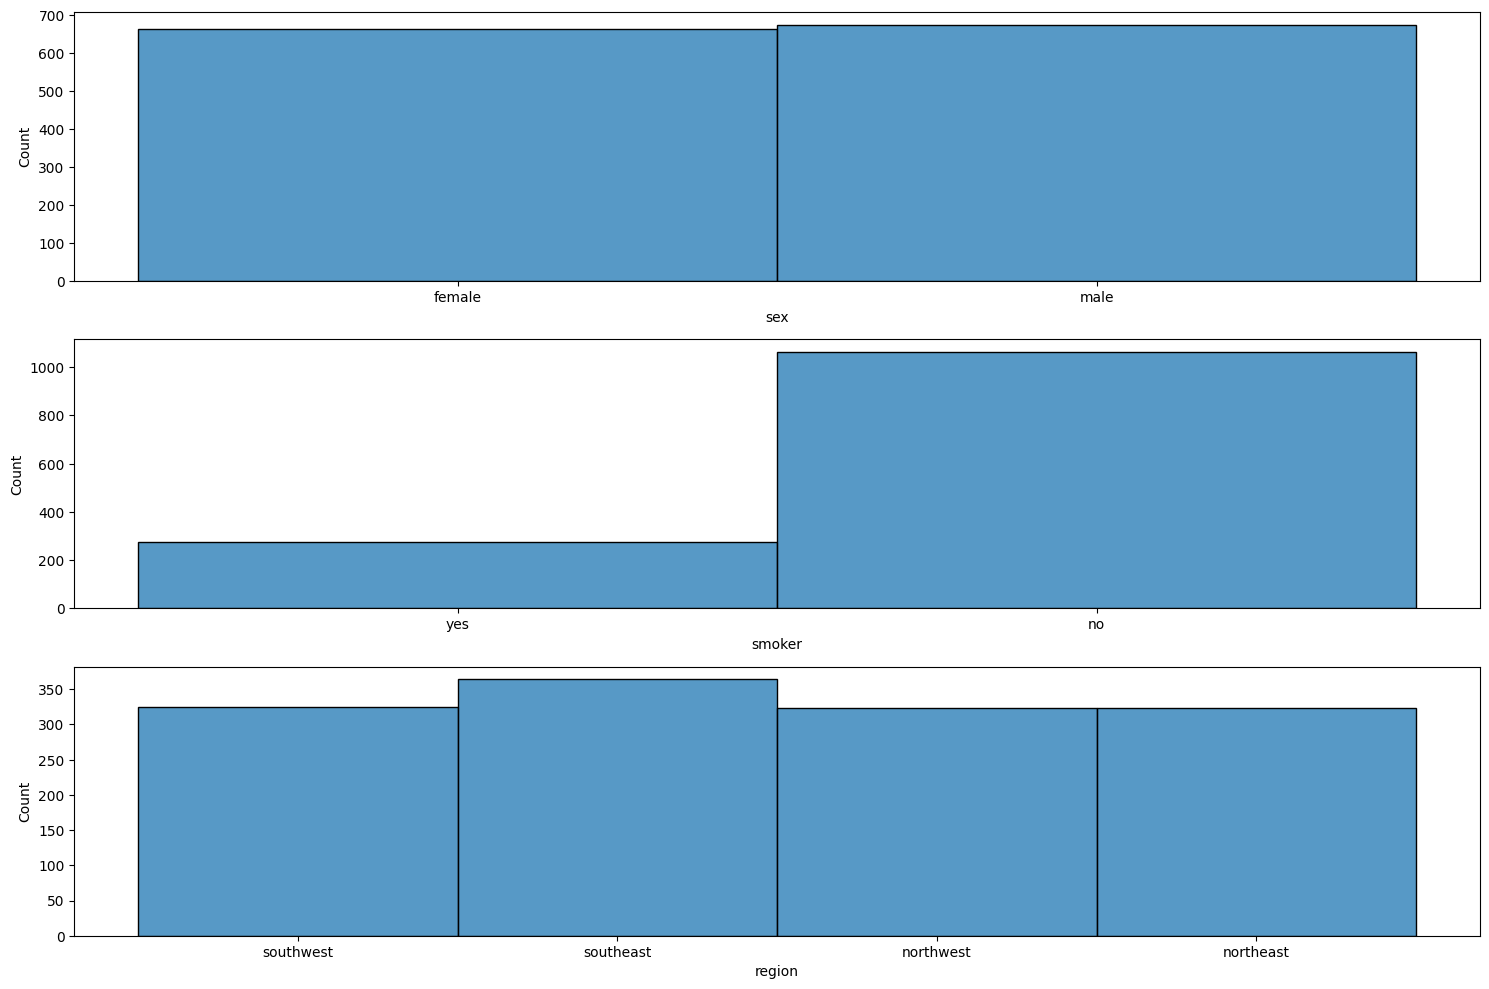

In [30]:
fig, axis = plt.subplots(3, 1, figsize=(15, 10))

sns.histplot(ax=axis[0], data=df, x='sex')
sns.histplot(ax=axis[1], data=df, x='smoker')
sns.histplot(ax=axis[2], data=df, x='region')

plt.tight_layout()

> ## Observaciones:
>
> - Tenemos aproximadamente el mismo número de hombres que de mujeres
> - La mayoría de beneficiarios no fuman
> - Tenemos aproximadamente el mismo número de personas por area residencial

#### Análisis de Variables Univariantes Numéricas

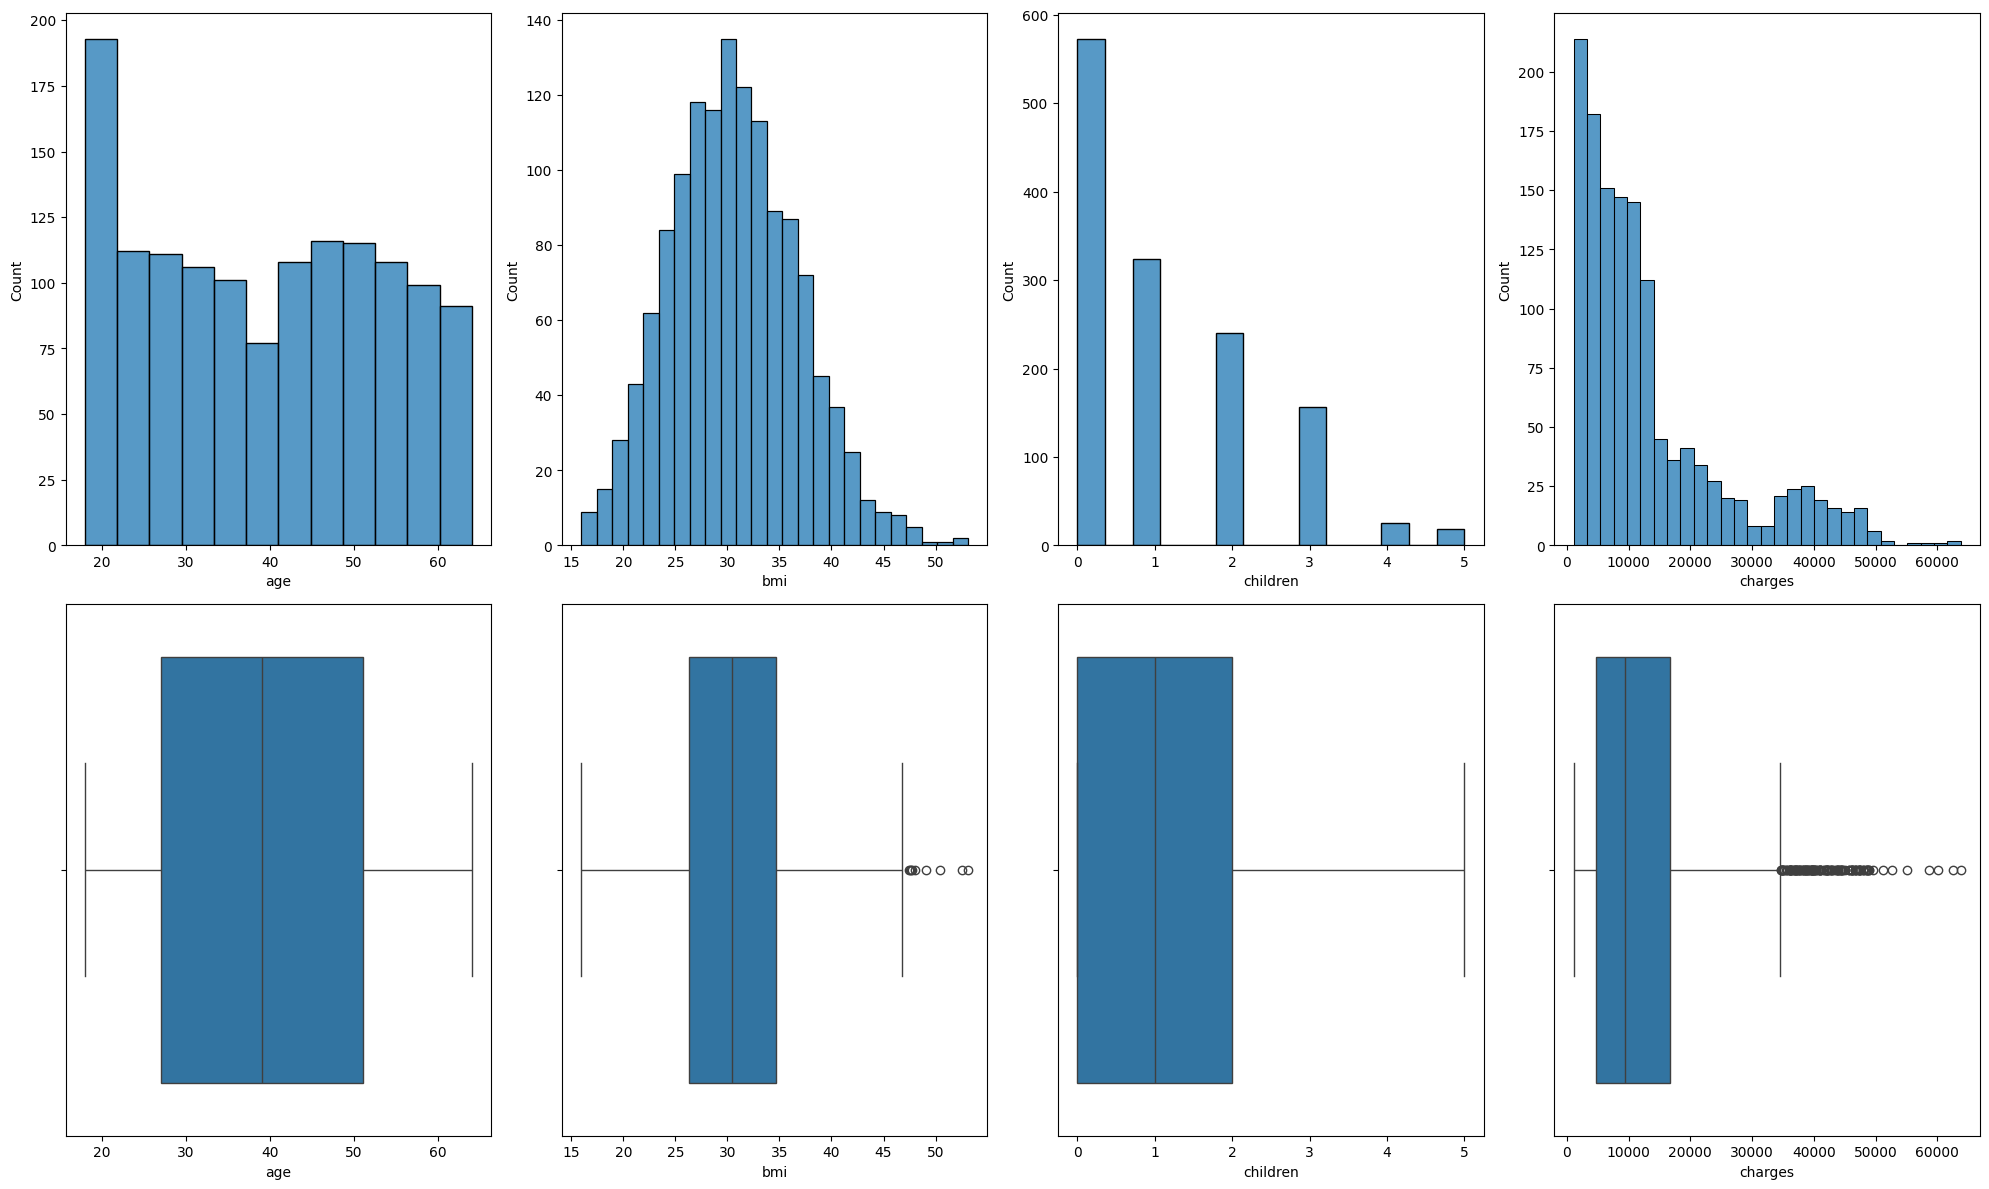

In [31]:
fig, axis = plt.subplots(2, 4, figsize=(20, 12))

sns.histplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='bmi')
sns.boxplot(ax=axis[1, 1], data=df, x='bmi')
sns.histplot(ax=axis[0, 2], data=df, x='children')
sns.boxplot(ax=axis[1, 2], data=df, x='children')
sns.histplot(ax=axis[0, 3], data=df, x='charges')
sns.boxplot(ax=axis[1, 3], data=df, x='charges')

plt.tight_layout()

> ## Observaciones:
>
> - `Age` y `bmi` tienen distribuciones aparentemente normales
> - `children` y `charges` tienen distribuciones asimétricas con los datos sesgados a la izquierda

#### Análisis de Variables Multivariante (numerico-numerico)

    charges - (age, bmi, children)

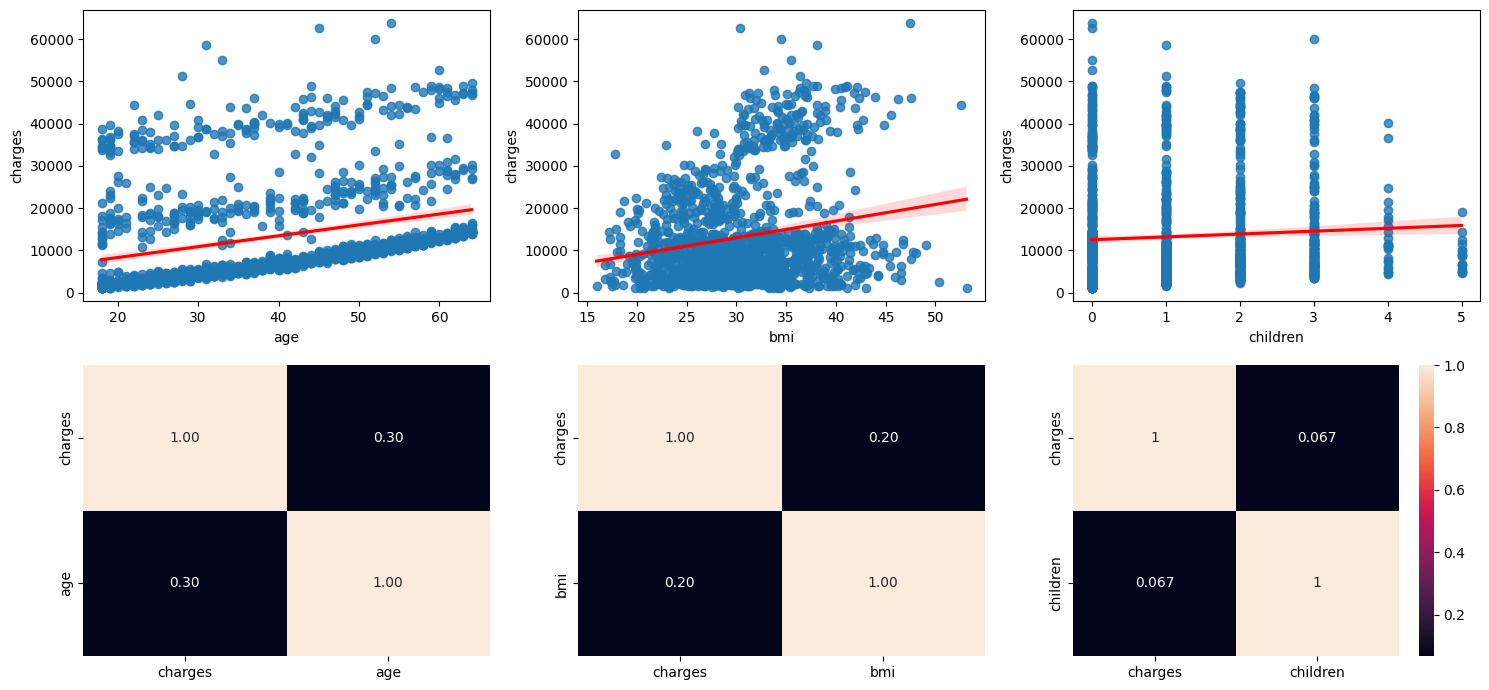

In [32]:
fig, axis = plt.subplots(2, 3, figsize=(15,7))

sns.regplot(ax=axis[0, 0], data=df, x='age', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'age']].corr(), annot=True, fmt='.2f', ax=axis[1, 0], cbar=False)
sns.regplot(ax=axis[0, 1], data=df, x='bmi', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'bmi']].corr(), annot=True, fmt='.2f', ax=axis[1, 1], cbar=False)
sns.regplot(ax=axis[0, 2], data=df, x='children', y='charges', line_kws={'color': 'red'})
sns.heatmap(df[['charges', 'children']].corr(), annot=True, ax=axis[1, 2])

plt.tight_layout()

> ## Observaciones:
>
> - 'Age' es la variable numérica que más relacion directa tiene sobre el target (0.3), si la edad sube la prima del seguro también sube.


#### Análisis de Variables Multivariante (numerico-categórico completo) 

In [33]:
# Creo columnas numéricas para las variables categóricas
df['sex_n'] = pd.factorize(df['sex'])[0]
df['smoker_n'] = pd.factorize(df['smoker'])[0]
df['region_n'] = pd.factorize(df['region'])[0]
df

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2
...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,1,1,2
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,3
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,1
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0


<Axes: >

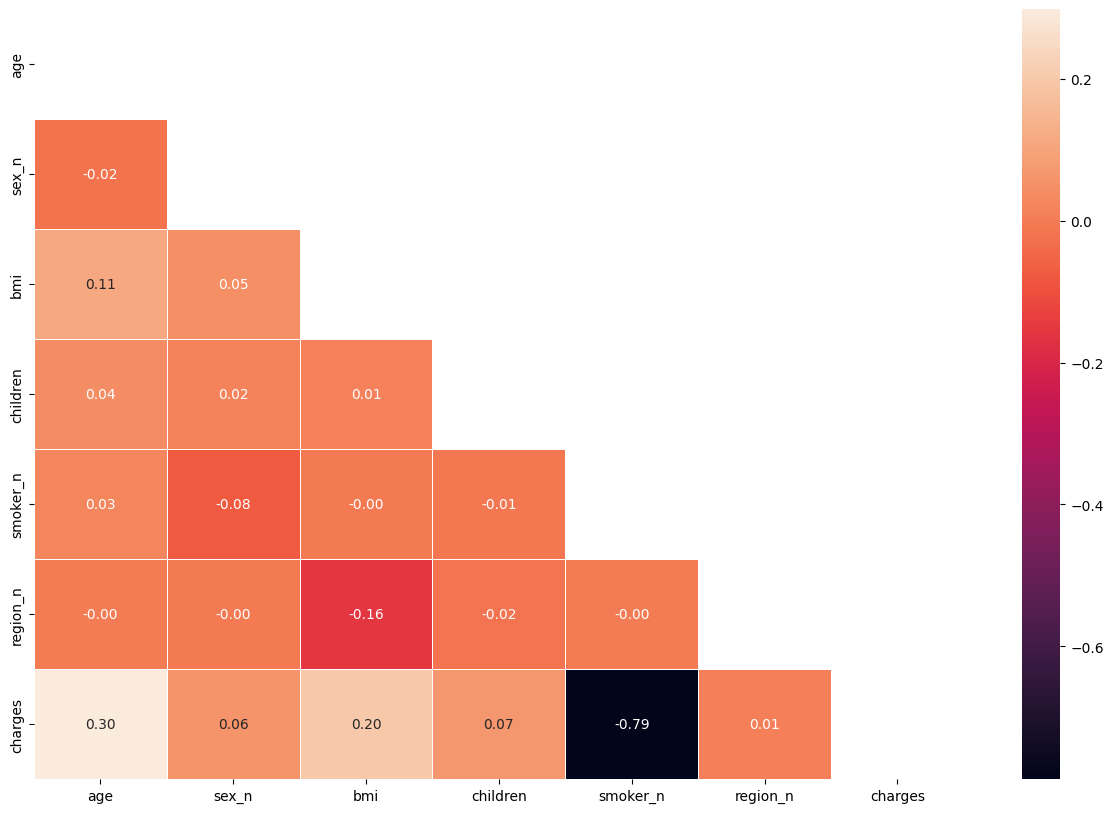

In [34]:
corr = df[['age', 'sex_n', 'bmi', 'children', 'smoker_n', 'region_n', 'charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt='.2f')

<Axes: xlabel='smoker_n', ylabel='charges'>

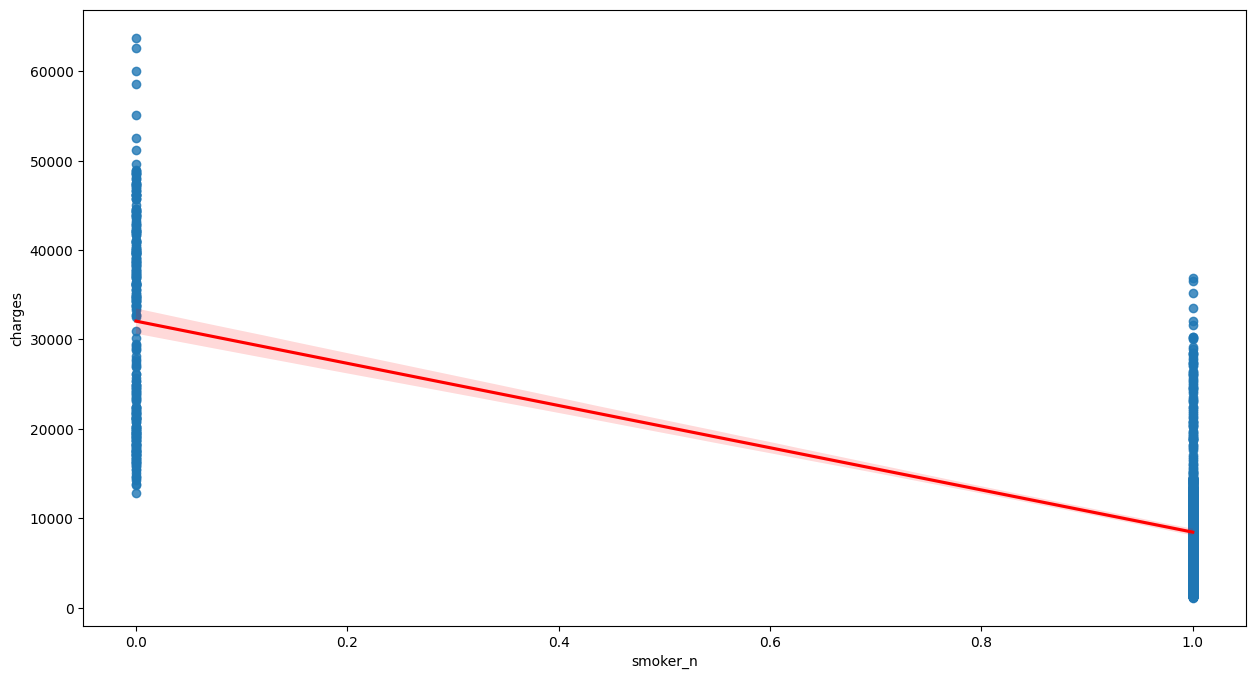

In [35]:
plt.subplots(figsize=(15, 8))

sns.regplot(data=df, x='smoker_n', y='charges', line_kws={'color': 'red'})

> ## Observaciones:
>
> - Existe una fuerte relación directa negatica entre `smoker` y el target, si los beneficiarios no fumadores suben la prima del seguro baja

### Ingeniería de características

#### Análisis de outliers

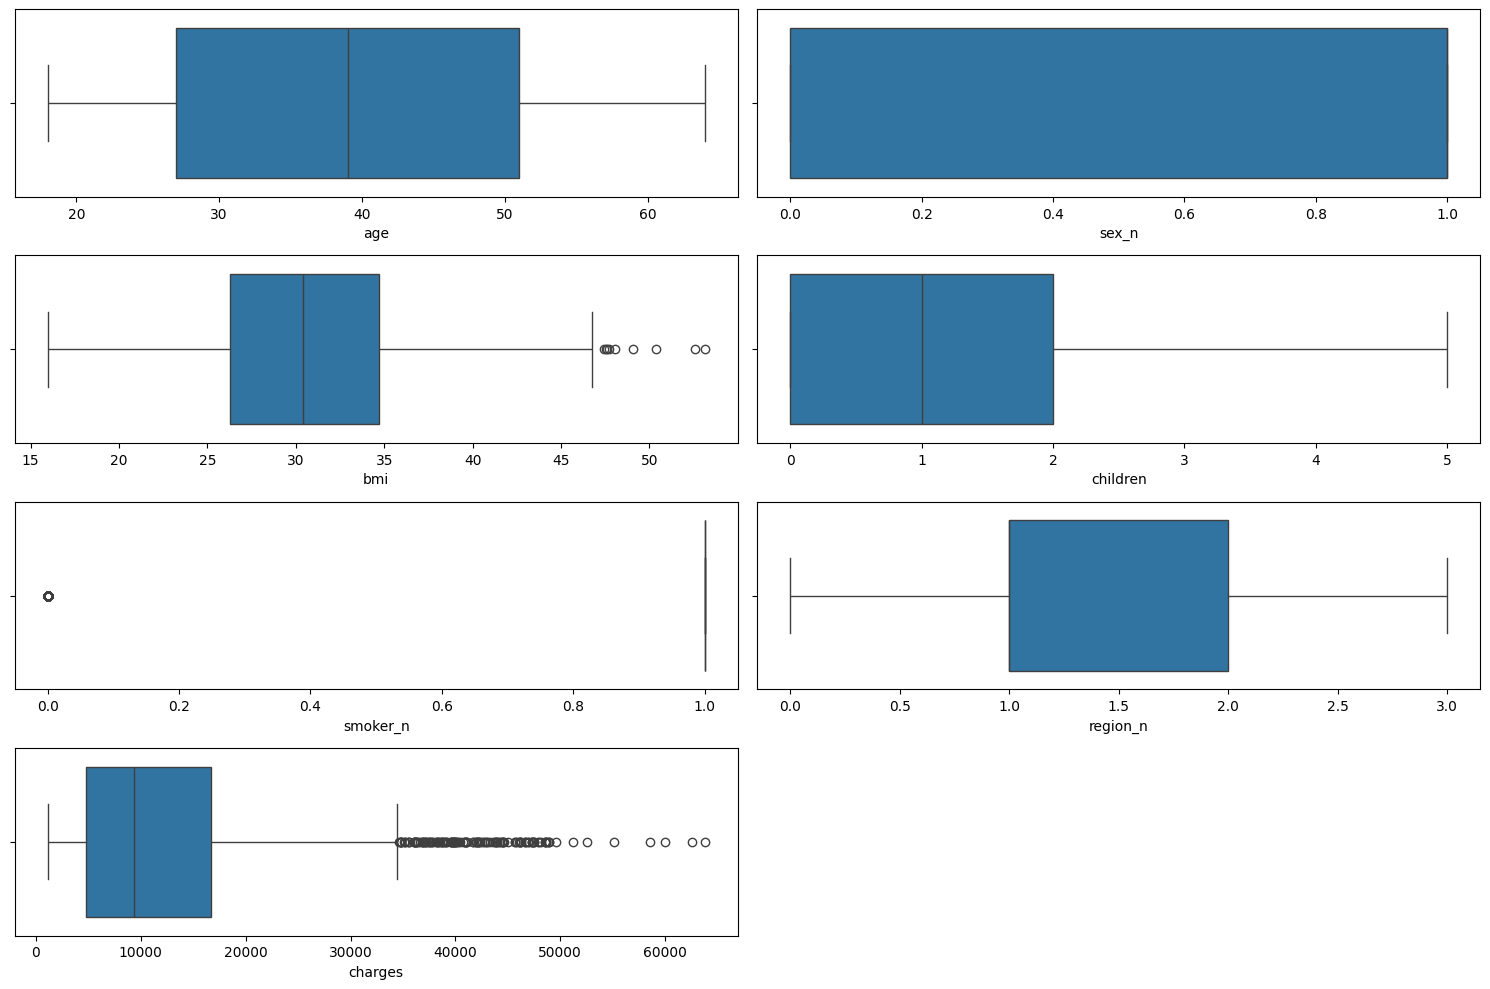

In [16]:
fig, axis = plt.subplots(4, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[0, 1], data=df, x='sex_n')
sns.boxplot(ax=axis[1, 0], data=df, x='bmi')
sns.boxplot(ax=axis[1, 1], data=df, x='children')
sns.boxplot(ax=axis[2, 0], data=df, x='smoker_n')
sns.boxplot(ax=axis[2, 1], data=df, x='region_n')
sns.boxplot(ax=axis[3, 0], data=df, x='charges')

plt.delaxes(ax=axis[3, 1])
plt.tight_layout()

> ## Observaciones:
> - Podemos determinar fácilmente que las variables afectadas por outliers son: `bmi`, `smoker` y `charges`
> - De momento vamos a mantener todos los outliers.

#### Análisis de valores faltantes

In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
sex_n       0
smoker_n    0
region_n    0
dtype: int64

> ## Observaciones:
> - No existen valores nulos

#### Inferencia de nuevas características

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [36]:
X = df.drop('charges', axis= 1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_test

,age,sex,bmi,children,smoker,region,sex_n,smoker_n,region_n
831,36,female,25.840,0,no,northwest,0,1,2
972,22,female,20.235,0,no,northwest,0,1,2
1179,31,male,29.810,0,yes,southeast,1,0,1
827,36,male,28.025,1,yes,northeast,1,0,3
933,45,female,35.300,0,no,southwest,0,1,0
...,...,...,...,...,...,...,...,...,...
1040,35,female,28.025,0,yes,northwest,0,0,2
395,46,male,19.855,0,no,northwest,1,1,2
14,27,male,42.130,0,yes,southeast,1,0,1
803,18,female,42.240,0,yes,southeast,0,0,1


### Scaling - Escalado Mínimo-Máximo (variables numéricas)

In [37]:
num_variables = ['age', 'sex_n', 'bmi', 'children', 'smoker_n', 'region_n']

min_max_scaler = MinMaxScaler()
# Ajustamos solo con los datos de entrenamiento
min_max_scaler.fit(X_train[num_variables])

X_train_scal = min_max_scaler.transform(X_train[num_variables])
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=num_variables)

X_test_scal = min_max_scaler.transform(X_test[num_variables])
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=num_variables)

X_train_scal.head(), X_test_scal.head()

(           age  sex_n       bmi  children  smoker_n  region_n
 1062  0.891304    1.0  0.669833       0.2       0.0  0.333333
 209   0.478261    1.0  0.672312       0.2       1.0  1.000000
 1309  0.500000    1.0  0.423654       0.4       1.0  0.000000
 1259  0.739130    0.0  0.175272       0.0       1.0  1.000000
 711   0.695652    0.0  0.185185       0.4       1.0  0.333333,
            age  sex_n       bmi  children  smoker_n  region_n
 831   0.391304    0.0  0.248520       0.0       1.0  0.666667
 972   0.086957    0.0  0.094176       0.0       1.0  0.666667
 1179  0.282609    1.0  0.357841       0.0       0.0  0.333333
 827   0.391304    1.0  0.308688       0.2       0.0  1.000000
 933   0.586957    0.0  0.509018       0.0       1.0  0.000000)

In [21]:
# Guardamos el scaler utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-min_max_scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

### Seleccción de Características

In [76]:
# Selecciona las 5 mejores características
selection_model = SelectKBest(f_regression, k=1)
selection_model.fit(X_train_scal, y_train)
bool_variables = selection_model.get_support()

X_train_sel = selection_model.transform(X_train_scal)
X_train_sel = pd.DataFrame(X_train_sel, index=X_train_scal.index, columns=X_train_scal.columns.values[bool_variables])

X_test_sel = selection_model.transform(X_test_scal)
X_test_sel = pd.DataFrame(X_test_sel, index=X_test_scal.index, columns=X_test_scal.columns.values[bool_variables])

X_train_sel.head(), X_test_sel.head()


(      smoker_n
 1062       0.0
 209        1.0
 1309       1.0
 1259       1.0
 711        1.0,
       smoker_n
 831        1.0
 972        1.0
 1179       0.0
 827        0.0
 933        1.0)

In [77]:
# Guardamos el slection_model utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-selection-model.pkl', 'wb') as file:
    pickle.dump(selection_model, file)

> ## Conclusiones
>
> EDA terminado, ya tenemos dos conjuntos de datos de entrenamientos y el de prueba para empezar a construir el modelo y ver los resultados de cada uno.
> - `X_train_scal`, `X_test_scal` ,`y_train` , `y_test`
> - `X_train_sel`, `X_test_sel` ,`y_train` , `y_test`


## Paso 4: Construimos un modelo de regresión lineal

### Análisis y visualización

In [42]:
X_test_scal

,age,sex_n,bmi,children,smoker_n,region_n
831,0.391304,0.0,0.248520,0.0,1.0,0.666667
972,0.086957,0.0,0.094176,0.0,1.0,0.666667
1179,0.282609,1.0,0.357841,0.0,0.0,0.333333
827,0.391304,1.0,0.308688,0.2,0.0,1.000000
933,0.586957,0.0,0.509018,0.0,1.0,0.000000
...,...,...,...,...,...,...
1040,0.369565,0.0,0.308688,0.0,0.0,0.666667
395,0.608696,1.0,0.083712,0.0,1.0,0.666667
14,0.195652,1.0,0.697095,0.0,0.0,0.333333
803,0.000000,0.0,0.700124,0.0,0.0,0.333333


> ## Observaciones
>
> - Conforme hemos visto en el EDA, la unica variable predictora que tiene relación directa con la variable objetico es `smoker`
> - El resto de variables predictoras tienen muy poca relación (correlacion baja), por lo que el modelo no va a tener muy buena precision

In [48]:
# Creamos el modelo con valores por defecto y lo entrenamos
model = LinearRegression()
model.fit(X_train_scal, y_train)  

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
intercept = model.intercept_
coefficient = model.coef_

intercept, coefficient

(np.float64(21179.97475473),
 array([ 12028.90384895,   -254.59764126,  12555.75943788,   2663.5221577 ,
        -24148.65812348,   1042.15973337]))

In [ ]:
# Coeficiente de determinación (R2)
model.score(X_train_scal, y_train)

0.7575280842933039

### Predicción del modelo

In [53]:
y_test

831      5266.36560
972      2527.81865
1179    19350.36890
827     20773.62775
933      7348.14200
           ...     
1040    20234.85475
395      7526.70645
14      39611.75770
803     38792.68560
234      6710.19190
Name: charges, Length: 268, dtype: float64

In [52]:
y_pred = model.predict(X_test_scal)
y_pred

array([ 5553.40818417,   -45.46787119, 29165.20344352, 31083.0142915 ,
       10482.87166961,  8052.88370855, 34357.27609688,  9088.72459627,
       34197.69871715,  3837.07085912, 23130.44099312,  7709.07475721,
        9581.92222028,  3014.43339111, 38190.53226944, 10105.44745527,
       14007.891315  , 11506.57788075, 29420.09175392,  3243.76633364,
        8145.13709402,  6181.5805205 , 30254.17456367,  8269.46266658,
        1037.7723036 ,  9458.12062231,  8119.16591693, 35311.24691857,
       12392.14019991,  1427.42403118,   688.0556123 , 11701.10837674,
        5010.25564297, 12529.91465886,  5691.66930017, 10682.06207194,
        3976.84748753, 15493.26289799,  7759.26898823,  8694.53831388,
       13027.82468713,  3428.66577578, 39986.38328004, 33810.48899197,
       10125.18040905,  1974.67275404, 13231.83728462, 32161.29608048,
       12124.32219618,  9685.51045531,  6673.68447845, 10802.65353344,
       11181.87905595, 28013.67135863, 12395.42431872, 13534.7447651 ,
      

### Evaluación del modelo

In [55]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),
           'RMSE': root_mean_squared_error(y_test, y_pred),
           'MAPE': mean_absolute_percentage_error(y_test, y_pred),
           'R^2': r2_score(y_test, y_pred), }

metrics

{'MSE': 34982022.94057997,
 'RMSE': 5914.56024912926,
 'MAPE': 0.3947920144593288,
 'R^2': 0.7137168510820229}

> ## Conclusiones
>
> - Corroboramos que el modelo no tiene buena precion (R2 < 80%)

### Optimización de resultados

In [84]:
X_train_sel

,smoker_n
1062,0.0
209,1.0
1309,1.0
1259,1.0
711,1.0
...,...
368,1.0
48,1.0
773,0.0
1232,1.0


In [85]:
# Creamos el modelo optimizado (utilizando los datos del algoritmo de selection) con valores por defecto y lo entrenamos
optimized_model = LinearRegression()
optimized_model.fit(X_train_sel, y_train)  

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [86]:
sel_intercept = optimized_model.intercept_
sel_coefficient = optimized_model.coef_

sel_intercept, sel_coefficient

(np.float64(32330.60686253332), array([-23958.6441077]))

In [87]:
# Coeficiente de determinación (R2)
optimized_model.score(X_train_sel, y_train)

0.6252256204324392

In [90]:
y_pred_sel = optimized_model.predict(X_test_sel)
y_pred_sel,y_test


(array([ 8371.96275483,  8371.96275483, 32330.60686253, 32330.60686253,
         8371.96275483,  8371.96275483, 32330.60686253,  8371.96275483,
        32330.60686253,  8371.96275483, 32330.60686253,  8371.96275483,
         8371.96275483,  8371.96275483, 32330.60686253,  8371.96275483,
         8371.96275483,  8371.96275483, 32330.60686253,  8371.96275483,
         8371.96275483,  8371.96275483, 32330.60686253,  8371.96275483,
         8371.96275483,  8371.96275483,  8371.96275483, 32330.60686253,
         8371.96275483,  8371.96275483,  8371.96275483,  8371.96275483,
         8371.96275483,  8371.96275483,  8371.96275483,  8371.96275483,
         8371.96275483,  8371.96275483,  8371.96275483,  8371.96275483,
         8371.96275483,  8371.96275483, 32330.60686253, 32330.60686253,
         8371.96275483,  8371.96275483,  8371.96275483, 32330.60686253,
         8371.96275483,  8371.96275483,  8371.96275483,  8371.96275483,
         8371.96275483, 32330.60686253,  8371.96275483,  8371.96

### Evaluación del modelo

In [89]:
metrics = {'MSE': mean_squared_error(y_test, y_pred_sel),
           'RMSE': root_mean_squared_error(y_test, y_pred_sel),
           'MAPE': mean_absolute_percentage_error(y_test, y_pred_sel),
           'R^2': r2_score(y_test, y_pred_sel), }
metrics

{'MSE': 50043412.20887903,
 'RMSE': 7074.136852569296,
 'MAPE': 0.793850975403211,
 'R^2': 0.590458629162379}